# Libraries

In [1]:
%reload_ext autoreload
%autoreload 2

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import itertools

from agentlab.analyze import inspect_results
from pathlib import Path

sns.set_context("notebook") # makes the text in the plots larger, for better visibility
%config InlineBackend.figure_format = 'svg' # makes the plots HD in the notebook
mpl.rcParams["figure.autolayout"] = True # enables tigh layout. Better multiplots
plt.rcParams['font.family'] = 'sans-serif'

# Constants

In [3]:
TASK_NAME_PREFIX ="workarena.servicenow."
OFFSET = len(TASK_NAME_PREFIX)
TECHNIQUE = "hpa"

data_paths = [
#    Path("/Users/montis/agentlab_results/genericagent-google-gemini-3-flash-preview-on-workarena-l1"),
    Path("/Users/montis/agentlab_results/genericagent-google-gemini-3-flash-preview-on-workarena-l1-baseline-30-steps"),
#    Path("/Users/montis/agentlab_results/2026-02-20_16-27-11_hpaagent-google-gemini-3-flash-preview-on-workarena-l1_684"),
#    Path("/Users/montis/agentlab_results/2026-02-24_16-21-01_hpaagent-google-gemini-3-flash-preview-on-workarena-l1_773"),
#    Path("/Users/montis/agentlab_results/2026-03-05_19-19-28_hpaagent-google-gemini-3-flash-preview-on-workarena-l1_815"),
    Path("/Users/montis/agentlab_results/2026-03-07_00-38-28_hpaagent-google-gemini-3-flash-preview-on-workarena-l1-903"),
#    Path("/Users/montis/agentlab_results/2026-02-26_17-02-54_hpaagent-openai-gpt-5-on-workarena-l1")
#    Path("/Users/montis/agentlab_results/2026-03-04_18-27-52_hpaagent-google-gemini-3-flash-preview-on-workarena-l1-task-name-workarena-servicenow-single-chart-value-retrieval")
#    Path("/Users/montis/agentlab_results/2026-03-04_18-49-17_hpaagent-google-gemini-3-flash-preview-on-workarena-l1-tree-update-review")
]
LEADERBOARD_PATH = Path("/Users/montis/Documents/OneDrive - Ipazia SpA/Workarena Hackathon/browsergym_workarena_l1_official_leaderboard_2026-03-06.xlsx")

# Functions for Processing and Plotting

In [23]:
def compute_accuracy(df: pd.DataFrame) -> float:
    return df["cum_reward"].mean() * 100

def model_name_with_accuracy(df: pd.DataFrame) -> str:
    base_model_name = df.reset_index()["agent.agent_name"].iloc[0]
    accuracy_str = str(compute_accuracy(df).round(1))
    return f"{base_model_name}_{accuracy_str}"

# def process_df(df: pd.DataFrame, technique: str | None = None) -> pd.DataFrame:
def process_df(df: pd.DataFrame) -> pd.DataFrame:
    processed_df = df.reset_index().groupby("env.task_name").agg({"cum_reward": "mean", "n_steps": "mean"}).reset_index()
    processed_df["cum_reward_std"] = df.reset_index().groupby("env.task_name")["cum_reward"].std().values
    processed_df["n_steps_std"] = df.reset_index().groupby("env.task_name")["n_steps"].std().values
    processed_df["model"] = [df["model"].iloc[0]] * len(processed_df)
    processed_df["env.task_name"] = [task_name[OFFSET:] for task_name in processed_df["env.task_name"]]
    return processed_df

def plot_agerage_reward(df: pd.DataFrame, save: bool = False):
    g = sns.catplot(
        data=df.sort_values(by=["model", "cum_reward"], ascending=[False, True]),
        x="cum_reward",
        y="env.task_name",
        hue="model",
        kind="bar",
        aspect=1.7,
    )
    g.set_axis_labels("Average Reward", "Task Name")
    g.ax.grid(True, axis="x", linestyle="--", linewidth=0.5)
    # g.legend.set_title(f"Model {BASELINE_MODEL}")
    plt.suptitle(f"Average Reward, Baseline vs {TECHNIQUE.upper()}")
    plt.subplots_adjust(top=0.93)

    for ax in g.axes.flat:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor('black')
            spine.set_linewidth(1)
    
    if save:
        plt.savefig(Path(f"plots/average-reward_{'_'.join(df.model.unique())}.png"), bbox_inches="tight", dpi=200)

def plot_average_step_count(df: pd.DataFrame, save: bool = False):
    g = sns.catplot(
        data=df.sort_values(by=["model", "n_steps"], ascending=[False, True]),
        x="n_steps",
        y="env.task_name",
        hue="model",
        kind="bar",
        aspect=1.7,
    )
    g.set_axis_labels("Average Step Count", "Task Name")
    g.ax.grid(True, axis="x", linestyle="--", linewidth=0.5)
    plt.axvline(x=15, linestyle="--", color="red", linewidth=1)
    # g.legend.set_title(f"Model {BASELINE_MODEL}")
    plt.xlim(0, 30)
    plt.suptitle(f"Average Step Count, Baseline vs {TECHNIQUE.upper()}")
    plt.subplots_adjust(top=0.93)

    for ax in g.axes.flat:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor('black')
            spine.set_linewidth(1)

    if save:
        plt.savefig(Path(f"plots/average-step-count_{'_'.join(df.model.unique())}.png"), bbox_inches="tight", dpi=200)

def plot_model_heatmap(df: pd.DataFrame, model_name: str, save: bool = False):
    # Prepare data
    model_df = df[df["model"] == model_name]
    pivoted_model_df = model_df.pivot(
        index="env.task_name", 
        columns="cum_reward", 
        values="n_steps"
    )

    plt.figure(figsize=(9, 6))

    # Calculate bounds for the colorbar
    min_val = np.floor(model_df["n_steps"].min())
    max_val = np.ceil(model_df["n_steps"].max())

    # Create the heatmap
    g = sns.heatmap(
        pivoted_model_df, 
        vmin=min_val,
        vmax=max_val,
        cmap="Spectral_r",
        cbar_kws={'label': 'Average Number of Steps'},
    )

    # --- COLORBAR CUSTOMIZATION ---
    cbar = g.collections[0].colorbar
    
    # Define where you want the ticks (e.g., 5 evenly spaced points)
    tick_locations = np.linspace(min_val, max_val, num=5)
    cbar.set_ticks(tick_locations)
    # Format the labels (e.g., adding 'steps' suffix or rounding)
    cbar.set_ticklabels([f"{int(x)}" for x in tick_locations])
    # ------------------------------

    # Axis formatting
    g.set_yticks(np.arange(len(pivoted_model_df.index)) + 0.5)
    g.set_yticklabels(pivoted_model_df.index, rotation=0)

    g.set_title(f"{model_name} Heatmap", pad=20, fontsize=14)
    g.set(xlabel="Average Cumulative Reward", ylabel="Task Name")

    for spine in g.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)
    
    plt.tight_layout()

    if save:
        plt.savefig(Path(f"plots/heatmap_{model_name}.png"), bbox_inches="tight", dpi=200)

def plot_combined_reward_step_count_filtered(df_list: list[pd.DataFrame], threshold: float, save: bool = False):
    # Ensure we have exactly 2 dataframes to compare for a 2x2 plot (permutations of 2 is 2)
    # If you have more than 2, you'll need to adjust the subplots logic.
    sorted_df_list = [df.sort_values(by="env.task_name").reset_index(drop=True) for df in df_list]
    model_permutations = list(itertools.permutations(sorted_df_list, 2))
    
    # Set up the figure
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    # Flatten or structure axes for easy access
    ax_pairs = [(axes[0, 0], axes[0, 1]), (axes[1, 0], axes[1, 1])]

    for i, (model_left, model_right) in enumerate(model_permutations):
        if i >= 2: 
            break # Limit to 2 rows based on subplot definition
        
        # Calculate mask based on threshold comparison
        # We use .values to avoid index alignment issues during subtraction
        diff = model_left["cum_reward"].values - model_right["cum_reward"].values
        mask = diff >= threshold
        
        filtered_model_left = model_left[mask]
        filtered_model_right = model_right[mask]
        filtered_df = pd.concat([filtered_model_left, filtered_model_right]).sort_values(by=["model", "cum_reward"], ascending=[False, True]).reset_index(drop=True)

        if filtered_df.empty:
            print(f"No tasks exceeded the threshold for permutation {i}")
            continue

        # 1. Left Plot: Average Reward
        sns.barplot(
            data=filtered_df,
            x="cum_reward",
            y="env.task_name",
            hue="model",
            ax=ax_pairs[i][0],
            orient='h'
        )
        ax_pairs[i][0].set_xlabel("Average Reward")
        ax_pairs[i][0].set_ylabel("Task Name")
        ax_pairs[i][0].grid(True, axis="x", linestyle="--", alpha=0.6)

        # 2. Right Plot: Average Step Count
        sns.barplot(
            data=filtered_df,
            x="n_steps",
            y="env.task_name",
            hue="model",
            ax=ax_pairs[i][1],
            orient='h'
        )
        ax_pairs[i][1].set_xlabel("Average Step Count")
        ax_pairs[i][1].set_ylabel("") 
        ax_pairs[i][1].grid(True, axis="x", linestyle="--", alpha=0.6)
        ax_pairs[i][1].axvline(x=15, linestyle="--", color="red", linewidth=1)
        ax_pairs[i][1].set_xlim(0, 30)

        # Cleanup individual legends
        ax_pairs[i][0].get_legend().remove()
        ax_pairs[i][1].get_legend().remove()

    # Global Legend logic
    handles, labels = ax_pairs[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', title="Model", bbox_to_anchor=(0.5, 0.98), ncol=2)

    # Styling
    for ax in axes.flat:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor('black')
            spine.set_linewidth(1)

    plt.tight_layout(rect=[0, 0, 1, 0.93])

    if save and not filtered_df.empty:
        models_str = '_'.join(filtered_df['model'].unique().astype(str))
        save_path = Path(f"plots/combined_metrics_{models_str}.png")
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight", dpi=200)
    
    plt.show()

def get_best_model_name(df_list: list[pd.DataFrame]) -> str:
    model_accuracy_dict = {}
    for df in df_list:
        model_name = df.reset_index()["model"].iloc[0]
        model_accuracy_dict[model_name] = compute_accuracy(df)
    return max(model_accuracy_dict, key=model_accuracy_dict.get)

def get_suboptimal_model_names(wide_processed_data: pd.DataFrame, best_model: str) -> list[str]:
    return [col for col in wide_processed_data.columns if col not in [best_model]]

def get_inconsistent_task_names(wide_processed_data: pd.DataFrame, best_model: str, suboptimal_models: list[str]) -> dict[str, list[str]]:
    inconsistent_tasks = {}

    for model in suboptimal_models:
        inconsistent_tasks[model] = wide_processed_data[wide_processed_data[best_model] < wide_processed_data[model]].index.values.tolist()

    for k, v in inconsistent_tasks.items():
        inconsistent_tasks[k] = [TASK_NAME_PREFIX + task_name for task_name in v]

    return inconsistent_tasks

def get_unsuccessful_task_seeds(df: pd.DataFrame, inconsistent_tasks_dict: dict[str, list[str]], best_model_name: str) -> list[pd.DataFrame]:
    unsuccessful_task_seeds_df_list = []

    for model_name, inconsistent_tasks_list in inconsistent_tasks_dict.items():
        inconsistent_task_seeds = df[(df["model"].isin([best_model_name, model_name])) & (df["env.task_name"].isin(inconsistent_tasks_list))]
        inconsistent_task_seeds_pivoted = inconsistent_task_seeds.pivot(index=["env.task_name", "env.task_seed"], columns="model", values="cum_reward")
        unsuccessful_task_seeds_df = inconsistent_task_seeds_pivoted[inconsistent_task_seeds_pivoted[best_model_name]<inconsistent_task_seeds_pivoted[model_name]]
        unsuccessful_task_seeds_df_list.append(unsuccessful_task_seeds_df.reset_index())
        
    return unsuccessful_task_seeds_df_list

# Average Reward and Step Count Comparisons

## Raw Data

In [5]:
browsergym_leaderboard = pd.read_excel(LEADERBOARD_PATH)

raw_df_list = [inspect_results.load_result_df(path) for path in data_paths]
for raw_df in raw_df_list:
    raw_df["model"] = [model_name_with_accuracy(raw_df)] * len(raw_df)
    
raw_data = pd.concat(raw_df_list)

Loading results: 100%|██████████| 330/330 [00:00<00:00, 2061.39it/s]


In [6]:
def compute_accuracy_cropping_steps(df: pd.DataFrame, model_name: str, steps: int = 15) -> float:
    df_reindexed = df.reset_index()
    df_reindexed_model = df_reindexed[df_reindexed["model"] == model_name]
    n_samples = len(df_reindexed_model)
    if n_samples != 330:
        print(f"Warning: {model_name} has {n_samples} samples instead of 330")
    return (df_reindexed_model[(df_reindexed_model["n_steps"] <= steps)].cum_reward.sum()/330*100).round(1)

def plot_steps_distribution(df: pd.DataFrame) -> None:
    df_reindexed = df.reset_index()
    sns.histplot(df_reindexed, x="n_steps", hue="model")

In [7]:
# plot_steps_distribution(raw_data)

In [8]:
# with gzip.open("/Users/montis/agentlab_results/2026-03-04_18-27-52_hpaagent-google-gemini-3-flash-preview-on-workarena-l1-task-name-workarena-servicenow-single-chart-value-retrieval/2026-03-04_18-27-56_HPAAgent-google_gemini-3-flash-preview_on_workarena.servicenow.single-chart-value-retrieval_769/step_2.pkl.gz", "rb") as f:
#     obj = pickle.load(f)  # or: pickle.load(f, encoding="latin1") for some old Python 2 pickles
 
# rich.print(obj.agent_info.extra_info["hpa_plan"])

## Processing

In [9]:
processed_df_list = [process_df(df=df) for df in raw_df_list]
processed_data = pd.concat(processed_df_list).reset_index(drop=True)

In [18]:
rows_to_add = []

browsergym_leaderboard_updated = browsergym_leaderboard.copy()
browsergym_leaderboard_updated["color"] = "#c0c0c0"

for index, row in browsergym_leaderboard_updated.iterrows():
    new_val = "-".join(row["agent"].split("-")[1:])
    browsergym_leaderboard_updated.at[index, "agent"] = new_val

for model in raw_data["model"].unique():
    row = {}
    row["agent"] = model
    row["score"] = (raw_data[raw_data["model"] == model].cum_reward.mean() * 100).round(2)
    row["score_std"] = (raw_data[raw_data["model"] == model].cum_reward.var() * 100).round(1)
    row["max_steps"] = raw_data[raw_data["model"] == model]["env.max_steps"].iloc[0]
    row["benchmark_specific"] = False
    row["benchmark_tuned"] = False
    row["color"] = "#5250da"
    row["n_steps"] = raw_data[raw_data["model"] == model]["n_steps"].mean()
    rows_to_add.append(row)

for row in rows_to_add:
    if row["agent"] == "GenericAgent-google_gemini-3-flash-preview_86.1":
        row["agent"] = "Gemini-3-flash"
    elif row["agent"] == "HPAAgent-google_gemini-3-flash-preview_90.3":
        row["agent"] = "HPA-Gemini-3-flash"

browsergym_leaderboard_updated = pd.concat([browsergym_leaderboard_updated, pd.DataFrame(rows_to_add)]).sort_values(by="score", ascending=False).reset_index(drop=True)

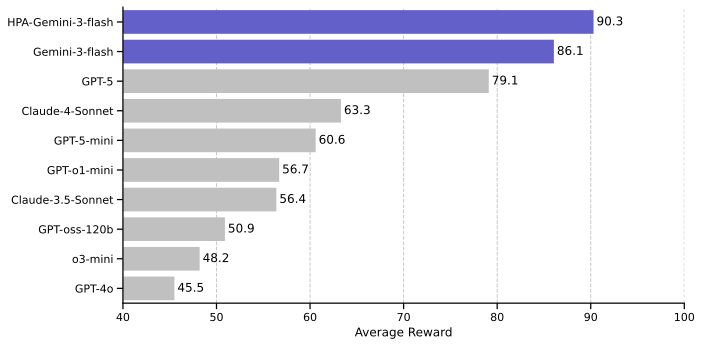

In [20]:
g = sns.catplot(
    data=browsergym_leaderboard_updated.head(10), 
    x="score", 
    y="agent", 
    kind="bar", 
    hue="agent",
    dodge=False, 
    palette=dict(zip(browsergym_leaderboard_updated.agent, browsergym_leaderboard_updated.color)), 
    legend=False,
    width=0.8, 
    aspect=2
)

g.set(xlim=(40, 100), ylabel="", xlabel="Average Reward")

for ax in g.axes.flat:
    ax.grid(axis='x', linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)
    for container in ax.containers:
        ax.bar_label(container, padding=3, fmt='%.1f')

plt.savefig(Path("plots/new_leaderboard.png"), bbox_inches="tight", dpi=200)

plt.show()

## Visualization

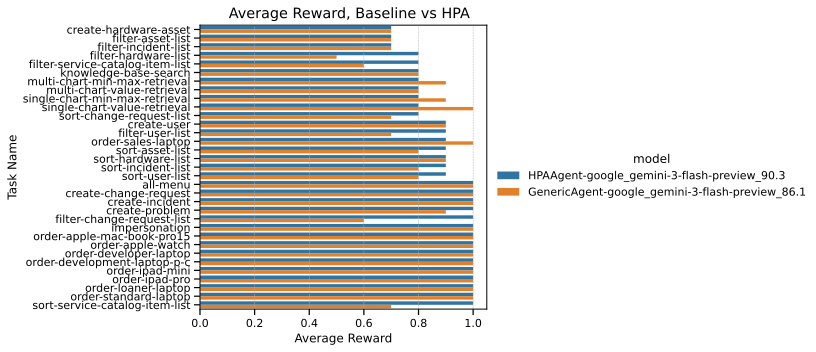

In [10]:
plot_agerage_reward(processed_data)

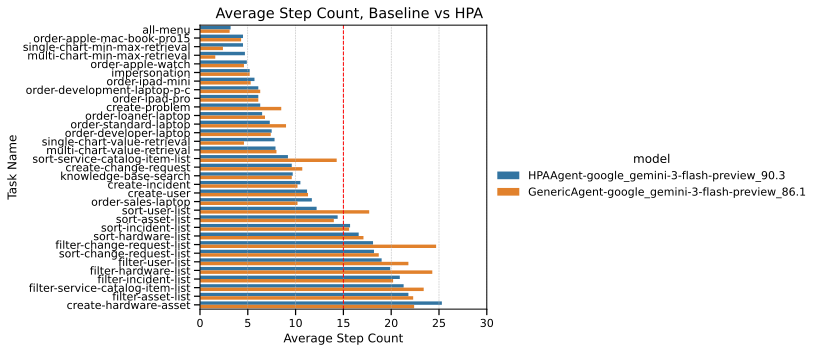

In [11]:
plot_average_step_count(processed_data)

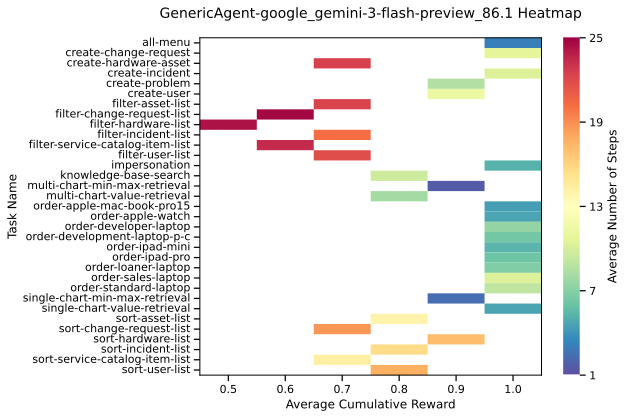

In [24]:
plot_model_heatmap(processed_data, "GenericAgent-google_gemini-3-flash-preview_86.1")

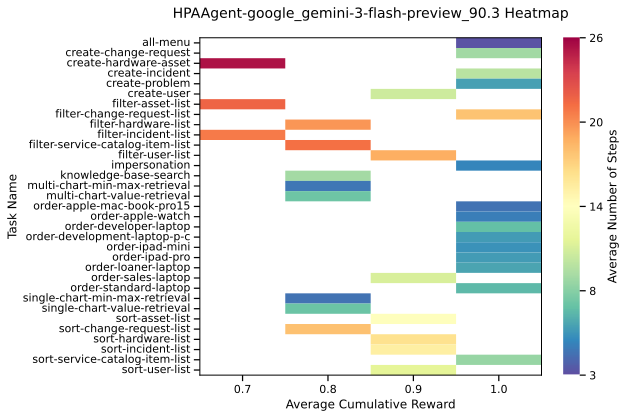

In [14]:
plot_model_heatmap(processed_data, "HPAAgent-google_gemini-3-flash-preview_90.3")

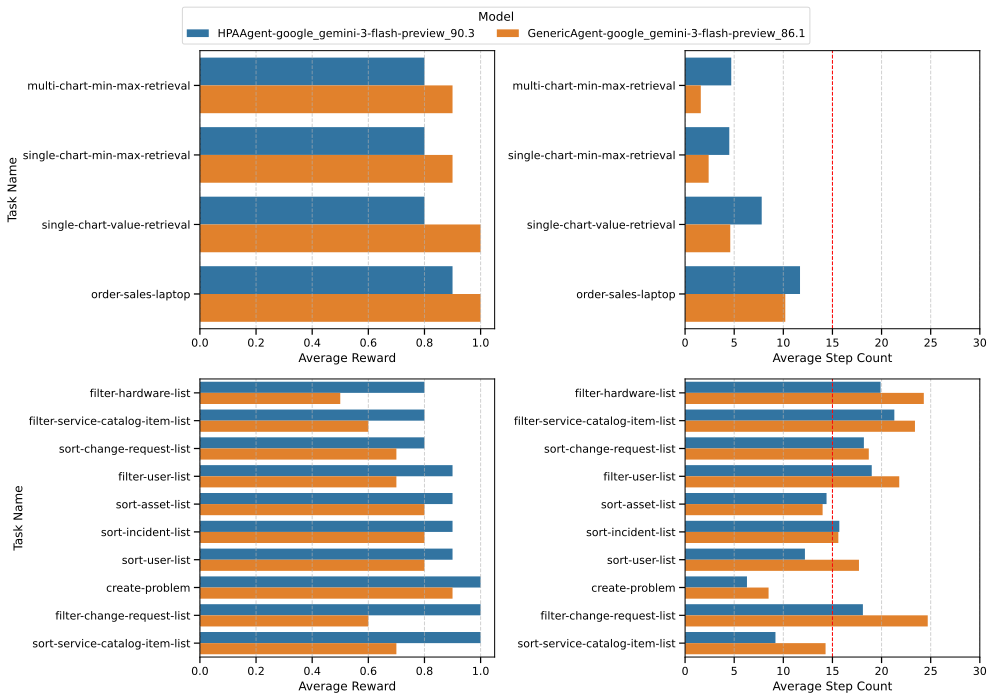

In [27]:
plot_combined_reward_step_count_filtered(processed_df_list, 0.05)

In [16]:
def plot_combined_reward_step_count(df: pd.DataFrame, save: bool = False):
    # Set up the figure with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8), sharey=True)
    sorted_df = df.sort_values(by=["model", "cum_reward"], ascending=[False, True])

    # 1. Left Plot: Average Reward
    sns.barplot(
        data=sorted_df,
        x="cum_reward",
        y="env.task_name",
        hue="model",
        ax=ax1,
        orient='h'
    )
    ax1.set_xlabel("Average Reward")
    ax1.set_ylabel("Task Name")
    ax1.grid(True, axis="x", linestyle="--", linewidth=0.5)

    # 2. Right Plot: Average Step Count
    sns.barplot(
        data=sorted_df,
        x="n_steps",
        y="env.task_name",
        hue="model",
        ax=ax2,
        orient='h'
    )
    ax2.set_xlabel("Average Step Count")
    ax2.set_ylabel("")  # Hide y-label as it's shared with the left plot
    ax2.grid(True, axis="x", linestyle="--", linewidth=0.5)
    ax2.axvline(x=15, linestyle="--", color="red", linewidth=1)
    ax2.set_xlim(0, 30)

    # Unified Legend Handling
    # Extract legend from the first axes and place it nicely
    handles, labels = ax1.get_legend_handles_labels()
    ax1.get_legend().remove()
    ax2.get_legend().remove()
    
    fig.legend(handles, labels, loc='upper center', title="Model", bbox_to_anchor=(0.5, 0.95))

    # General styling (applying your spine aesthetics)
    for ax in [ax1, ax2]:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor('black')
            spine.set_linewidth(1)

    # Title and Layout
    # plt.suptitle(f"Agent Performance: Baseline vs {TECHNIQUE.upper()}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.85]) # Leave room for the suptitle

    if save:
        models_str = '_'.join(df.model.unique())
        plt.savefig(Path(f"plots/combined_metrics_{models_str}.png"), bbox_inches="tight", dpi=200)
    
    plt.show()

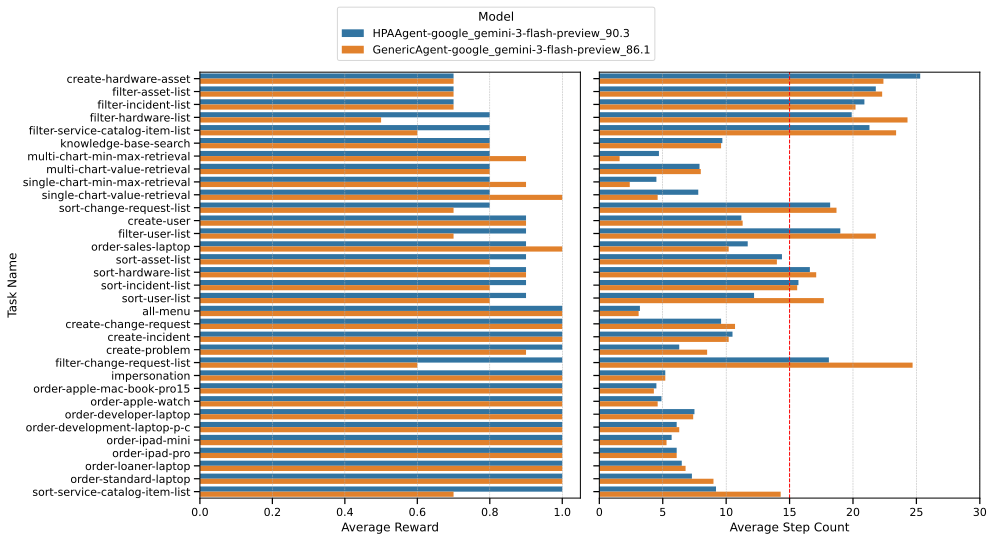

In [17]:
plot_combined_reward_step_count(processed_data)

# Inconsistencies Detection

In [15]:
wide_processed_data = processed_data.pivot(index="env.task_name", columns="model", values="cum_reward")

In [16]:
best_model_name = get_best_model_name(processed_df_list)
suboptimal_model_names = get_suboptimal_model_names(wide_processed_data=wide_processed_data, best_model=best_model_name)
inconsistent_tasks_dict = get_inconsistent_task_names(wide_processed_data=wide_processed_data, best_model=best_model_name, suboptimal_models=suboptimal_model_names)

In [17]:
raw_df_list_index_reset = [raw_df.reset_index() for raw_df in raw_df_list]
raw_data_index_reset = pd.concat(raw_df_list_index_reset).reset_index(drop=True)

In [18]:
unsuccessful_task_seeds_df_list = get_unsuccessful_task_seeds(df=raw_data_index_reset, inconsistent_tasks_dict=inconsistent_tasks_dict, best_model_name=best_model_name)

In [19]:
unsuccessful_task_seeds_df_list[0]

model,env.task_name,env.task_seed,HPAAgent-google_gemini-3-flash-preview_77.3,HPAAgent-google_gemini-3-flash-preview_81.5
0,workarena.servicenow.create-user,387,1.0,0.0
1,workarena.servicenow.create-user,942,1.0,0.0
2,workarena.servicenow.filter-asset-list,201,1.0,0.0
3,workarena.servicenow.filter-asset-list,270,1.0,0.0
4,workarena.servicenow.filter-asset-list,455,1.0,0.0
5,workarena.servicenow.filter-asset-list,815,1.0,0.0
6,workarena.servicenow.filter-change-request-list,251,1.0,0.0
7,workarena.servicenow.filter-change-request-list,701,1.0,0.0
8,workarena.servicenow.filter-change-request-list,724,1.0,0.0
9,workarena.servicenow.filter-hardware-list,52,1.0,0.0


In [20]:
unsuccessful_task_seeds_df_list[1]

IndexError: list index out of range